In [1]:
import os

import torch
from torch import nn

from src.utils.global_constants import MODELS_DIR
from src.utils.datasets import EmbeddingDataset
from src.utils.train_test import (
    train_class_incremental,
    get_study_sessions,
    train_data_permutation,
)
from src.nn_modules.mlp import BaselineMLP
from src.nn_modules.kan import BaselineKAN
from src.nn_modules.regularized_kan import EWCLoss

# The random seed is fixed to ensure reproducibility of results
torch.manual_seed(42)
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
device

device(type='cuda')

In [2]:
# Create a directory for trained models if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

#### Datasets and training parameters

In [3]:
# Offline training parameters
learning_rate = 8e-4
batch_size = 256
criterion = nn.CrossEntropyLoss()
num_epochs = 100
early_stopping = 10
# Number of class labels in the first study session in CIL
base_size = 100
# Number of class labels in the study sessions starting from the second in CIL
session_size = 1
# Number of study sessions to perform with different feature vectors permutations
# in a data permutation experiment
num_sessions = 4

# Precomputed elmbeddings of images from the CUB200 dataset generated by ResNet50 model
trainset = EmbeddingDataset("cub200_train_embed.pt")
testset = EmbeddingDataset("cub200_test_embed.pt")
# Groups of class labels to be trained on during each study session
study_sessions = get_study_sessions(testset, base_size, session_size, device)

#### Class Incremental Learning

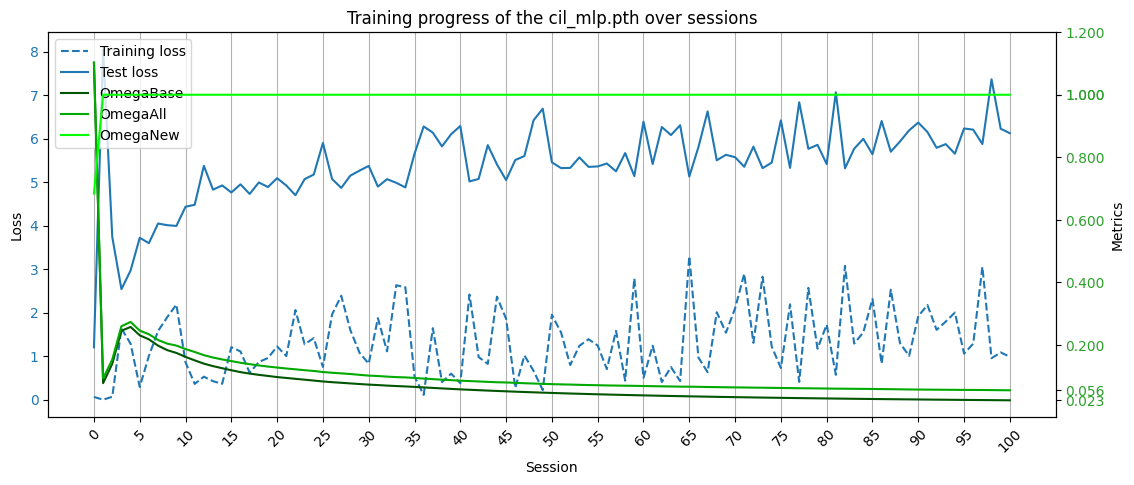

The model's weights are saved to /root/spbu-bachelor-thesis/src/models/cil_mlp.pth


In [4]:
model = BaselineMLP()
optimizer = torch.optim.NAdam(model.parameters(), lr=learning_rate)
train_class_incremental(
    model=model,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="cil_mlp.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

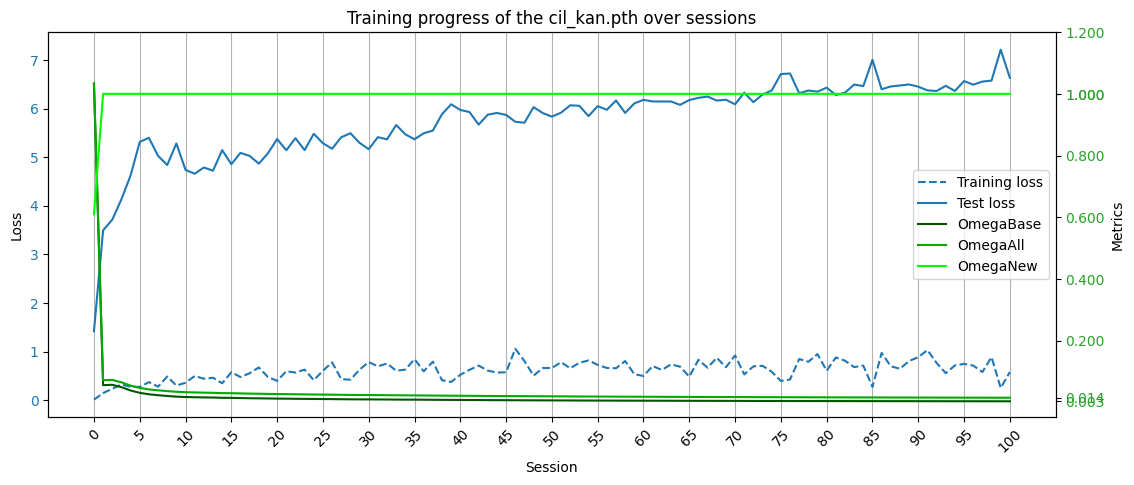

The model's weights are saved to /root/spbu-bachelor-thesis/src/models/cil_kan.pth


In [5]:
model = BaselineKAN()
optimizer = torch.optim.NAdam(model.parameters(), lr=learning_rate)
train_class_incremental(
    model=model,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="cil_kan.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

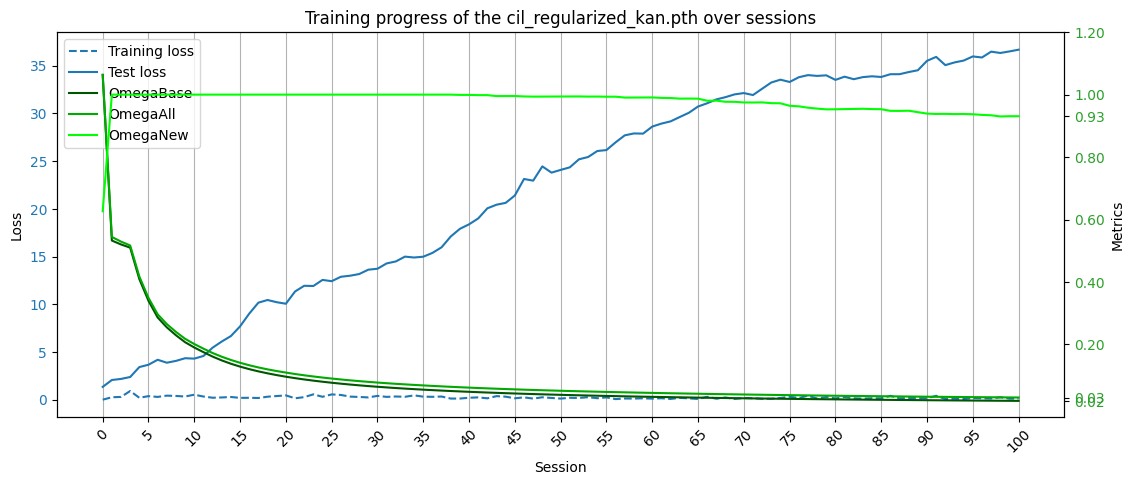

The model's weights are saved to /root/spbu-bachelor-thesis/src/models/cil_regularized_kan.pth


In [6]:
model = BaselineKAN()
optimizer = torch.optim.NAdam(model.parameters(), lr=learning_rate)
regularized_criterion = EWCLoss(
    criterion, model, device=device, lambda_=1e6, decay=0.99
)
train_class_incremental(
    model=model,
    trainset=trainset,
    testset=testset,
    criterion=regularized_criterion,
    optimizer=optimizer,
    save_path="cil_regularized_kan.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

#### Data Permutation Experiment

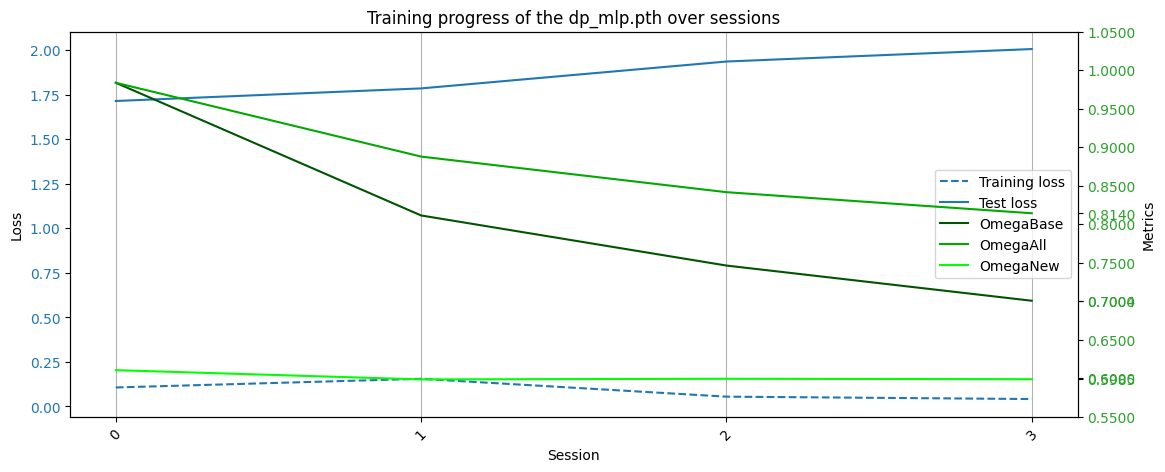

The model's weights are saved to /root/spbu-bachelor-thesis/src/models/dp_mlp.pth


In [7]:
model = BaselineMLP()
optimizer = torch.optim.NAdam(model.parameters(), lr=learning_rate)
train_data_permutation(
    model=model,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="dp_mlp.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

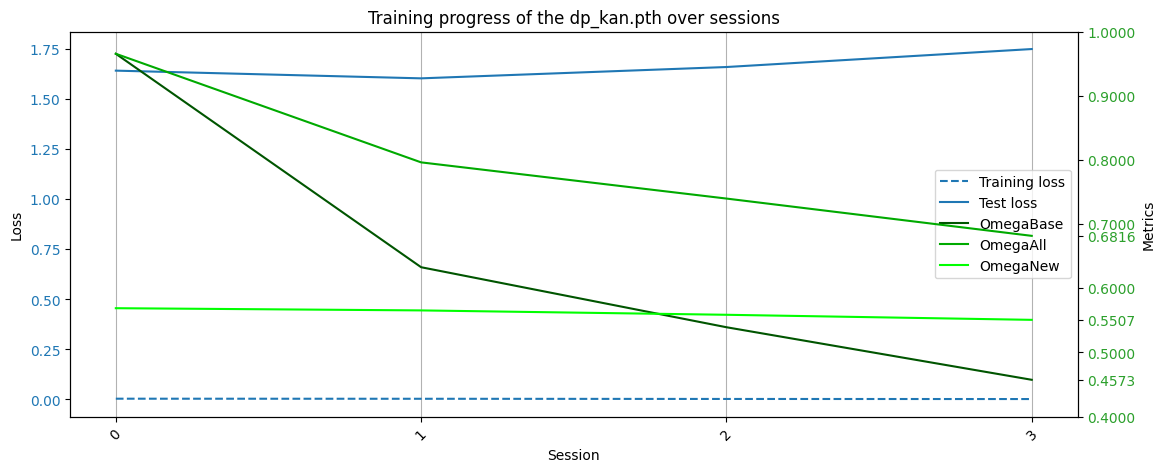

The model's weights are saved to /root/spbu-bachelor-thesis/src/models/dp_kan.pth


In [8]:
model = BaselineKAN()
optimizer = torch.optim.NAdam(model.parameters(), lr=learning_rate)
train_data_permutation(
    model=model,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="dp_kan.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

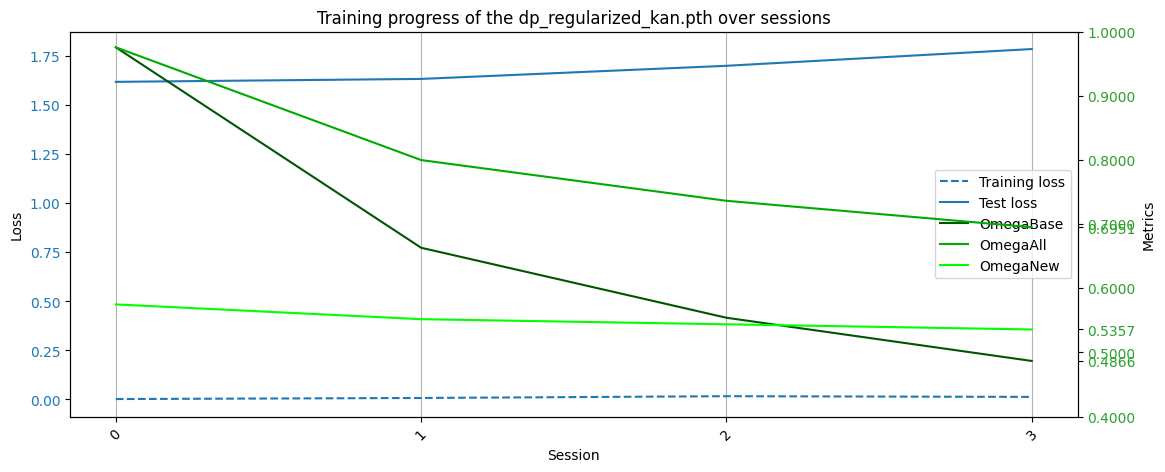

The model's weights are saved to /root/spbu-bachelor-thesis/src/models/dp_regularized_kan.pth


In [9]:
model = BaselineKAN()
optimizer = torch.optim.NAdam(model.parameters(), lr=learning_rate)
regularized_criterion = EWCLoss(
    criterion, model, device=device, lambda_=1e7, decay=0.95
)
train_data_permutation(
    model=model,
    trainset=trainset,
    testset=testset,
    criterion=regularized_criterion,
    optimizer=optimizer,
    save_path="dp_regularized_kan.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)